In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

sim_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu'

reg = 'CT'
eve_list = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_225_compile_combined.csv'


#load file in pandas
eve = pd.read_csv(eve_list,sep = ',')

for eve_row in [33,3907,40000]:
    eve_id = eve['id'][eve_row]
    mw = eve['Mag'][eve_row]
    sr = eve['SR'][eve_row]
    print(eve_id,mw,sr)

    #read the file in one of the sim event folder
    eve_path = os.path.join(sim_dir,eve_id)
    file_list = glob.glob(eve_path + '/*.nc')
    file_list.sort()
    # print(*file_list,sep = "\n")
    # print('')
    # for i in range(len(file_list)):
    #     print(file_list[i])
    #     ds = xr.open_dataset(file_list[i])
    #     print(ds)


    # Set up the figure and axes
    plt.ion()
    fig, ax = plt.subplots(9, 1, figsize=(6, 10), sharex=True, sharey=True)

    # Customize the style
    plt.style.use('seaborn-v0_8-colorblind')

    dst = xr.open_dataset(file_list[-1]) #time series is the last file in the list       
    dsdz = xr.open_dataset(file_list[0]) #deformation file
    dsd = xr.open_dataset(file_list[1]) #depth file

    # Loop through the data
    start = 35
    for i in range(35, 44):
        # Plot the data
        ax[i - start].plot(dst.time[:480], dst.eta[:480, i], label=f'id:{i}', color='grey', linewidth=1)

        # Set axis off
        ax[i - start].set_axis_off()

        # Calcualate max eta across time and locations
        max_eta = np.max(np.abs(dst.eta[:, i])).values.round(2)

    # Adjust layout to prevent clipping of titles
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # Set a main title for the entire figure
    fig.suptitle(f'Source: {sr} Mw: {mw} Max Eta: {max_eta}m', fontsize=16)
    # Show the plot
    plt.show()
    plt.close(fig)

    
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    dsd.z.plot(ax=ax2, cmap='hot_r', levels=np.linspace(0, 5, 11),add_colorbar=False )
    ax2.axis('equal')
    ax2.set_axis_off()
    
    max_flow_depth = np.max(dsd.z).values.round(2)
    fig2.suptitle(f'Source: {sr} Mw: {mw} Max Flow Depth: {max_flow_depth}m', fontsize=16)
    plt.show()
    plt.close(fig2)


    fig3, ax3 = plt.subplots(figsize=(8, 6))
    dsdz.deformation.plot(ax=ax3, cmap='seismic', levels=np.linspace(-2, 2, 21), add_colorbar=False)
    ax3.axis('equal')
    ax3.set_axis_off()  
    max_seafloor_disp = np.max(np.abs(dsdz.deformation)).values.round(2)
    fig3.suptitle(f'Source: {sr} Mw: {mw} Max Displacement: {max_seafloor_disp}m', fontsize=16)
    plt.show()
    plt.close(fig3)
    
    


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
import cartopy.feature as cfeature
import cartopy.crs as ccrs


sim_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu'
reg = 'CT'
eve_list = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_225_compile_combined.csv'


eve = pd.read_csv(eve_list)

SR_TYPES = ['HL', 'CL', 'BS']

N_EXAMPLES = 10

#filter based on source region type
filtered_events = {
    sr: eve[(eve['SR'] == sr) & (eve['truemax'] > 4)].sample(N_EXAMPLES, random_state=42)
    for sr in SR_TYPES
}

#filter based on event type (deformation only) which are always BS type SR
EVENT_TYPES = [0]
deformation_events = {
    et: eve[(eve['event_type'] == et) & (eve['max_absdz'] > 1)].sample(N_EXAMPLES, random_state=42)
    for et in EVENT_TYPES
}



In [66]:
def plot_timeseries_frame(ax, dst, sr, mw, eve_id):
    ax[:] = ax[:]  # keeps array shape
    start = 35
    for j, i in enumerate(range(35, 44)):
        ax[j].clear()
        ax[j].plot(dst.time[:480], dst.eta[:480, i], color='dodgerblue', lw=1)
        ax[j].set_axis_off()
    max_eta = np.max(np.abs(dst.eta[:, 35:44])).values.round(2)
    return max_eta

def plot_depth_frame(ax, dsd, sr, mw, eve_id):
    ax.clear()
    im = dsd.z.plot(
        ax=ax,
        cmap='hot_r',
        levels=np.linspace(0, 5, 11),
        add_colorbar=False
    )
    ax.axis('equal')
    ax.set_axis_off()

    max_depth = float(dsd.z.max().values.round(2))
    return max_depth

def plot_deformation_frame(ax, dsdz, sr, mw, eve_id):
    ax.clear()
    dsdz.deformation.plot(
        ax=ax,
        cmap='PiYG',
        levels=np.linspace(-4, 4, 11),
        add_colorbar=False
    )
    ax.axis('equal')
    ax.set_axis_off()

    max_def = float(np.abs(dsdz.deformation).max().values.round(2))
    return max_def

def plot_epicenter(ax, lon, lat):
    # Plot epicentre
    ax.plot(
        lon, lat,
        marker='*',
        markersize=10,
        markeredgecolor='black',
        markeredgewidth=0,
        color='crimson',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    # Map background
    ax.set_extent([13.0, 28.0, 30.0, 40.0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.92', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    # ax.coastlines(resolution='10m', linewidth=0.8)

    # Clean look
    ax.set_axis_off()

    return ax

def make_gif(fig, update_func, frames, filename):
    writer = PillowWriter(fps=1)
    with writer.saving(fig, filename, dpi=300):
        for i in frames:
            update_func(i)
            writer.grab_frame()




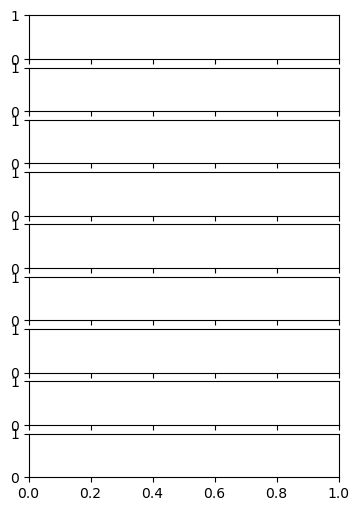

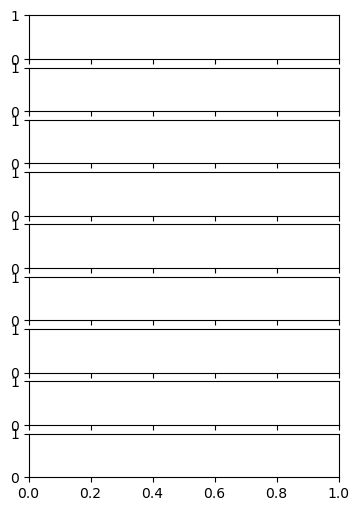

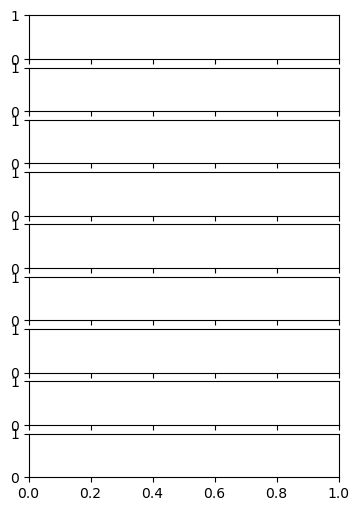

In [70]:
import os
import glob
import xarray as xr

out_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/plots/ras'

plt.style.use('seaborn-v0_8-colorblind')

for sr_type, df_sr in filtered_events.items():

    # --- EVE INFO and EPICENTER GIF ---
    fig_eve, ax_eve = plt.subplots(
        figsize=(6, 4),
        subplot_kw=dict(projection=ccrs.PlateCarree())
    )

    def update_name_epicentre(i):
        ax_eve.clear()

        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']
        lat = row['lat']
        lon = row['lon']
        row_number = row.name

        plot_epicenter(ax_eve, lon, lat)

        fig_eve.suptitle(
            f"SR: {sr_type} | Mw: {mw} | Event #: {row_number}",
            fontsize=14
        )

    make_gif(
        fig_eve,
        update_name_epicentre,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/{sr_type}_eve.gif"
    )
    plt.close(fig_eve)

    # --- TIME SERIES GIF ---
    fig_ts, ax_ts = plt.subplots(9, 1, figsize=(4, 6), sharex=True, sharey=True)

    # --- TIME SERIES GIF ---
    fig_ts, ax_ts = plt.subplots(9, 1, figsize=(4, 6), sharex=True, sharey=True)

    def update_ts(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dst = xr.open_dataset(files[-1])

        max_eta = plot_timeseries_frame(ax_ts, dst, sr_type, mw, eve_id)

        fig_ts.suptitle(f"Max η: {max_eta} m", fontsize=14)

    make_gif(
        fig_ts,
        update_ts,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/{sr_type}_timeseries.gif"
    )
    plt.close(fig_ts)


    # --- FLOW DEPTH GIF ---
    fig_fd, ax_fd = plt.subplots(figsize=(4, 6))

    def update_fd(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dsd = xr.open_dataset(files[1])

        max_depth = plot_depth_frame(ax_fd, dsd, sr_type, mw, eve_id)

        fig_fd.suptitle(f"Max Flow Depth: {max_depth} m", fontsize=14)

    make_gif(
        fig_fd,
        update_fd,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/{sr_type}_flow_depth.gif"
    )
    plt.close(fig_fd)

    # --- DEFORMATION GIF ---
    fig_df, ax_df = plt.subplots(figsize=(4, 6))

    def update_df(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dsdz = xr.open_dataset(files[0])

        max_def = plot_deformation_frame(ax_df, dsdz, sr_type, mw, eve_id)

        fig_df.suptitle(f"Max Displacement: {max_def} m", fontsize=14)


    make_gif(
        fig_df,
        update_df,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/{sr_type}_deformation.gif"
    )
    plt.close(fig_df)


In [67]:
import os
import glob
import xarray as xr

out_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/plots/ras'

plt.style.use('seaborn-v0_8-colorblind')

for events,df_sr in deformation_events.items():

    # --- EVE INFO and EPICENTER GIF ---
    fig_eve, ax_eve = plt.subplots(
        figsize=(6, 4),
        subplot_kw=dict(projection=ccrs.PlateCarree())
    )

    def update_name_epicentre(i):
        ax_eve.clear()

        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']
        lat = row['lat']
        lon = row['lon']
        row_number = row.name

        plot_epicenter(ax_eve, lon, lat)

        fig_eve.suptitle(
            f"SR: {sr_type} | Mw: {mw} | Event #: {row_number}",
            fontsize=14
        )

    make_gif(
        fig_eve,
        update_name_epicentre,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/Def_eve.gif"
    )
    plt.close(fig_eve)

    # --- TIME SERIES GIF ---
    fig_ts, ax_ts = plt.subplots(9, 1, figsize=(4, 6), sharex=True, sharey=True)

    def update_ts(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dst = xr.open_dataset(files[-1])

        max_eta = plot_timeseries_frame(ax_ts, dst, sr_type, mw, eve_id)

        fig_ts.suptitle(f"Max η: {max_eta} m", fontsize=14)

    make_gif(
        fig_ts,
        update_ts,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/Def_timeseries.gif"
    )
    plt.close(fig_ts)

    # --- FLOW DEPTH GIF ---
    fig_fd, ax_fd = plt.subplots(figsize=(4, 6))

    def update_fd(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dsd = xr.open_dataset(files[1])

        max_depth = plot_depth_frame(ax_fd, dsd, sr_type, mw, eve_id)

        fig_fd.suptitle(f"Max Flow Depth: {max_depth} m", fontsize=14)

    make_gif(
        fig_fd,
        update_fd,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/Def_flow_depth.gif"
    )
    plt.close(fig_fd)

    # --- DEFORMATION GIF ---
    fig_df, ax_df = plt.subplots(figsize=(4, 6))

    def update_df(i):
        row = df_sr.iloc[i]
        eve_id = row['id']
        mw = row['Mag']

        files = sorted(glob.glob(os.path.join(sim_dir, eve_id, '*.nc')))
        dsdz = xr.open_dataset(files[0])

        max_def = plot_deformation_frame(ax_df, dsdz, sr_type, mw, eve_id)

        fig_df.suptitle(f"Max Displacement: {max_def} m", fontsize=14)


    make_gif(
        fig_df,
        update_df,
        frames=range(len(df_sr)),
        filename=f"{out_dir}/Def_deformation.gif"
    )
    plt.close(fig_df)
